In [ ]:
import pandas as pd

df = pd.read_csv("risultati/experiment.csv", )

Index(['number_of_points', 'result_in_points', 'final_area', 'exec_time',
       'number_of_thread', 'machine_label'],
      dtype='str')

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [ ]:
err = ((df.result_in_points.sum() / df.number_of_points.sum()) * 4) - math.pi
print(f'{err:.20f}')
print(f'{df.final_area.loc[df.number_of_points == df.number_of_points.max()].mean()-math.pi:.20f}')

## Qualcosa non mi torna, la somma con più punti non ha un approssimazione migliore di tutti i test

-0.00000642736106692965
-0.00000415296479339133


In [ ]:
df['percentage_error'] = df.final_area - math.pi

,number_of_points,result_in_points,final_area,exec_time,number_of_thread,machine_label,percentage_error
0,100000,78479,3.139160,0.00152,1,Laptop,-2.432654e-03
1,100000,78340,3.133600,0.00122,2,Laptop,-7.992654e-03
2,100000,78358,3.134320,0.00146,3,Laptop,-7.272654e-03
3,100000,78473,3.138920,0.00134,4,Laptop,-2.672654e-03
4,100000,78538,3.141520,0.00117,5,Laptop,-7.265359e-05
...,...,...,...,...,...,...,...
91,10000000000,7853972752,3.141589,31.04667,12,Laptop,-3.552790e-06
92,10000000000,7853976442,3.141591,30.75371,13,Laptop,-2.076790e-06
93,10000000000,7853980559,3.141592,28.49643,14,Laptop,-4.299898e-07
94,10000000000,7853963502,3.141585,28.91951,15,Laptop,-7.252790e-06


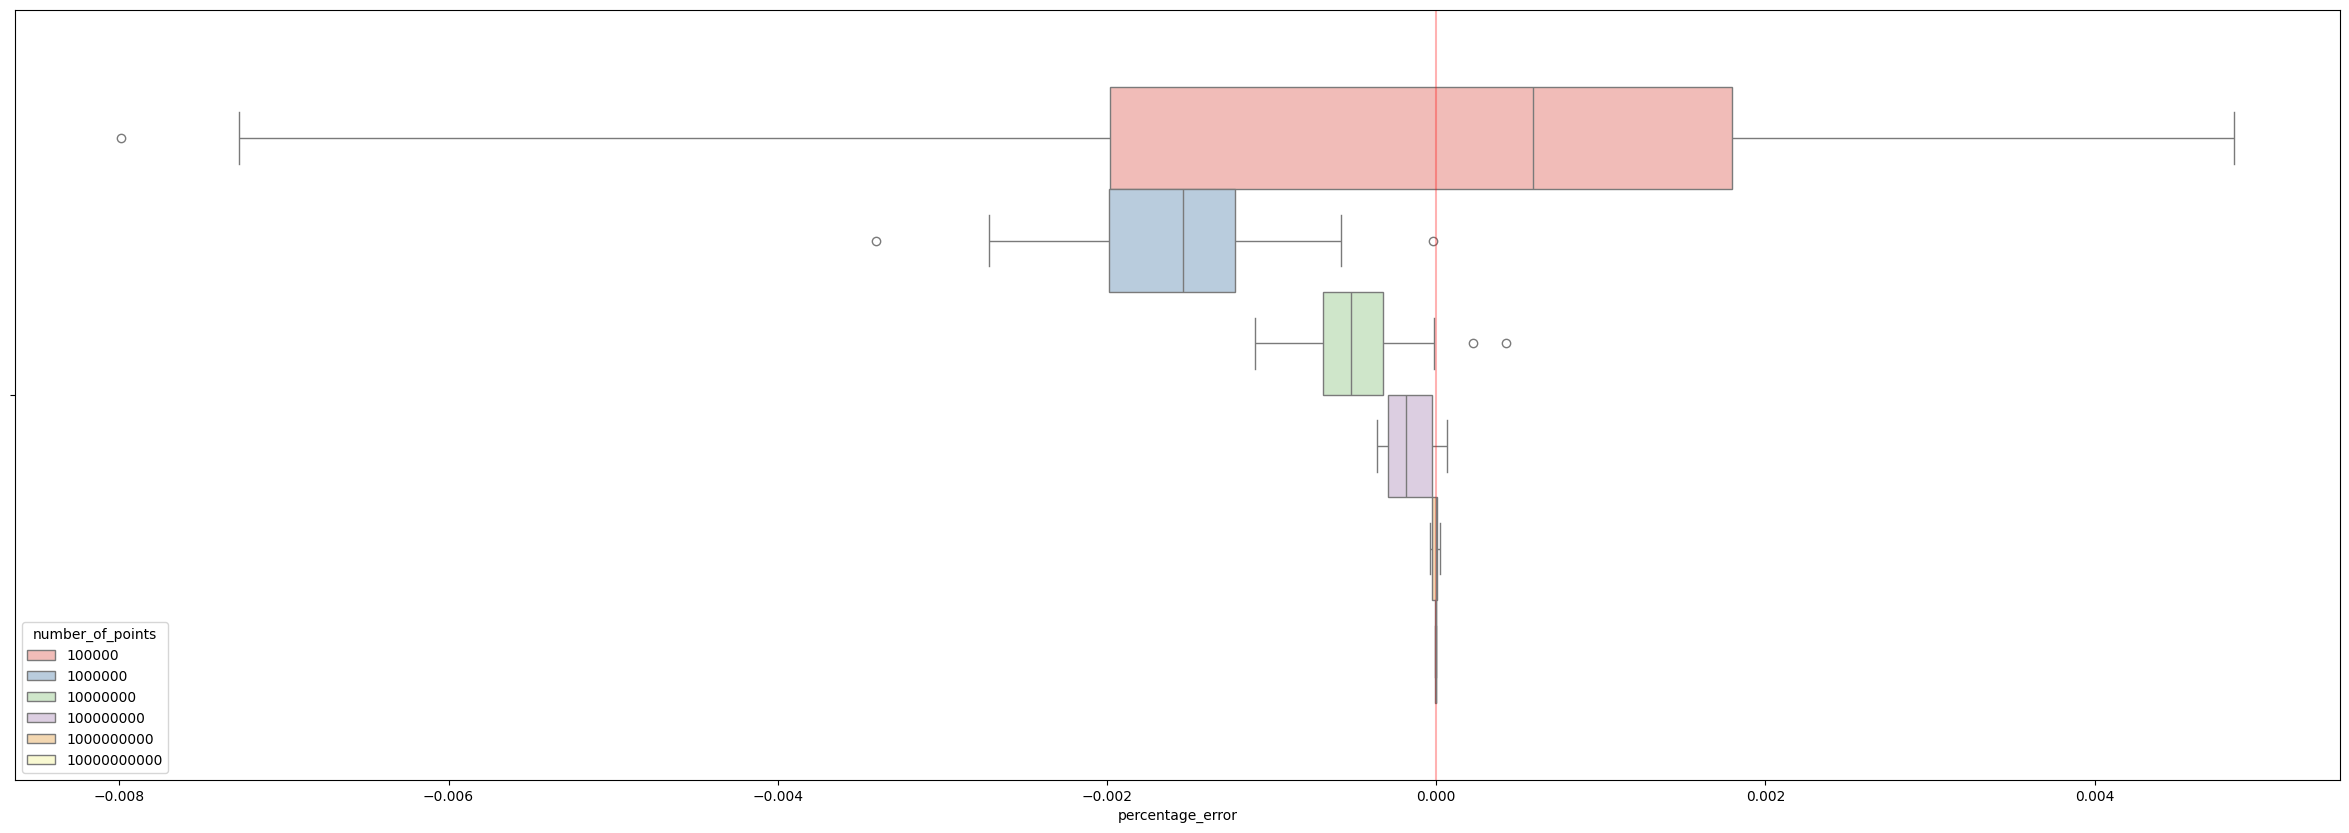

In [ ]:


f, ax = plt.subplots(1,1, figsize=(30,10))
sns.boxplot(df, x='percentage_error', hue='number_of_points', palette='Pastel1')
plt.axvline(x = 0, color = 'red', label = 'zero', alpha=0.3)

<Axes: xlabel='exec_time', ylabel='percentage_error'>

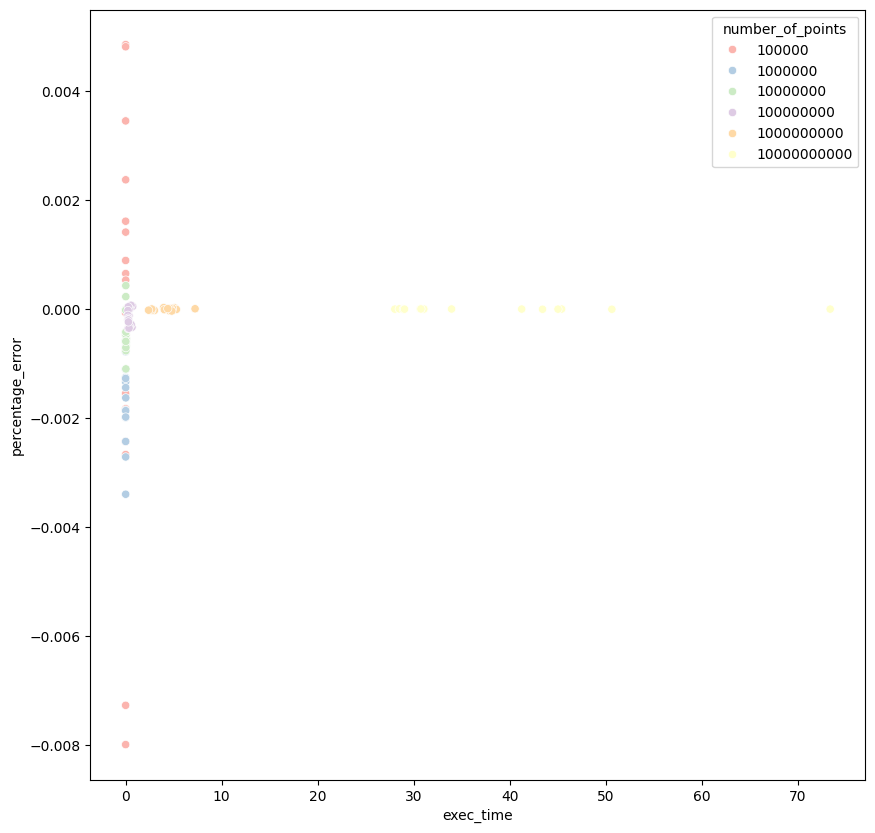

In [ ]:
f, ax = plt.subplots(figsize=(10,10))
sns.scatterplot(df, y='percentage_error', x='exec_time', hue='number_of_points', palette='Pastel1')
## BELLO SCHIFO DI GRAFICO

<Axes: >

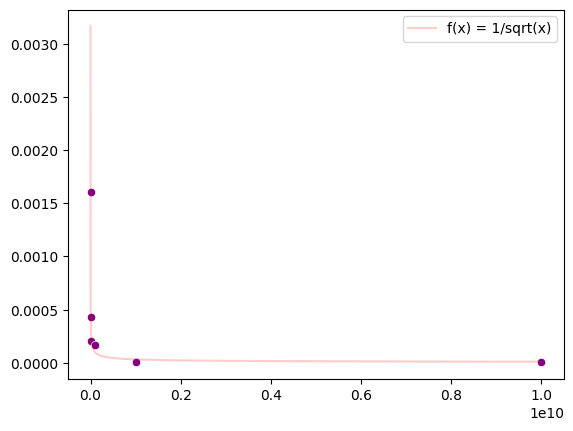

In [107]:
import numpy as np
ls = []
for n in df.number_of_points.unique():
    ls.append(abs(df.loc[df.number_of_points == n , 'percentage_error'].mean()))

sns.scatterplot(y = ls, x = df.number_of_points.unique(), color="purple")
x = np.arange(100000,df.number_of_points.max(),100000)
y = 1 / (x ** 0.5)

sns.lineplot(x = x, y = y, color="red", label="f(x) = 1/sqrt(x)", alpha=0.2)

In [144]:
## voglio mostrare la correlazione tra tempo e thread
row = pd.Series()
for n in df.number_of_points.unique():
    time_series = df.loc[df.number_of_points == n, 'exec_time']
    row = pd.concat([row,(time_series - time_series.mean()) / time_series.std()])
    # print("standard_dev :", time_series.std())
    # print("meain:", time_series.mean())
    # print((time_series - time_series.mean()) / time_series.std())
df["norm_time"] = row
df

,number_of_points,result_in_points,final_area,exec_time,number_of_thread,machine_label,percentage_error,norm_time
0,100000,78479,3.139160,0.00152,1,Laptop,-2.432654e-03,-0.533537
1,100000,78340,3.133600,0.00122,2,Laptop,-7.992654e-03,-0.618846
2,100000,78358,3.134320,0.00146,3,Laptop,-7.272654e-03,-0.550599
3,100000,78473,3.138920,0.00134,4,Laptop,-2.672654e-03,-0.584723
4,100000,78538,3.141520,0.00117,5,Laptop,-7.265359e-05,-0.633064
...,...,...,...,...,...,...,...,...
91,10000000000,7853972752,3.141589,31.04667,12,Laptop,-3.552790e-06,-0.531734
92,10000000000,7853976442,3.141591,30.75371,13,Laptop,-2.076790e-06,-0.555894
93,10000000000,7853980559,3.141592,28.49643,14,Laptop,-4.299898e-07,-0.742049
94,10000000000,7853963502,3.141585,28.91951,15,Laptop,-7.252790e-06,-0.707158


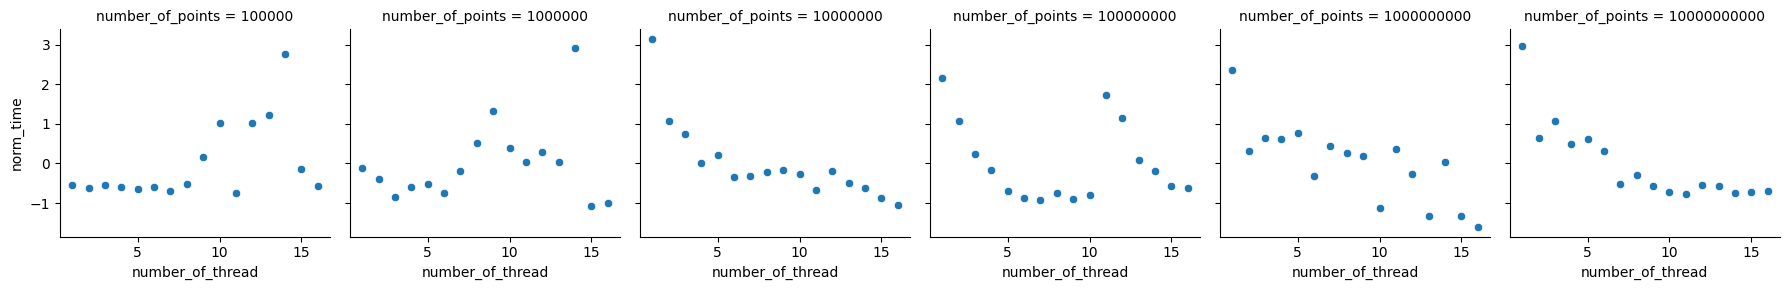

In [164]:
grid = sns.FacetGrid(df, col='number_of_points' )
grid.map(sns.scatterplot,'number_of_thread', 'norm_time')
#sns.scatterplot(df, x='norm_time', y = 'number_of_thread', hue='number_of_points', palette='Pastel1')

più thread non vuoldire sempre più veloce, nel esperimento 4 notiamo che fino a 10 decresce, ma a 11 aumenta di improvvisamente per poi continuare a decrescere